# Forecasting AAPL Volatility with GARCH and Financial-News Sentiment

This project evaluates whether lagged daily financial-news sentiment provides
incremental predictive value beyond a baseline GARCH(1,1) model for one-day-ahead
AAPL volatility forecasts.

The experiment uses an expanding window: each forecast is produced using only
information available before the corresponding return is observed.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from arch import arch_model
from tqdm.auto import tqdm

## 2. Market data and returns

Adjusted AAPL closing prices are downloaded from Yahoo Finance. Daily log return is
defined as $r_t = \log(P_t/P_{t-1})$. Returns are multiplied by 100 during model
estimation for numerical stability and converted back to decimal units for evaluation.

In [3]:
# Download dataset
ticker = "AAPL"

raw_data = yf.download(
    ticker,
    start="2010-02-10",
    end="2020-06-04",
    auto_adjust=True,
    progress=False
)
# Calculate P_{t} / P_{t-1}
data = pd.DataFrame({"Close": raw_data["Close"].squeeze()})
data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))
data = data.dropna(subset=["Log_Return"])
data.head()

               Close  Log_Return
Date                            
2010-02-11  5.942146    0.018030
2010-02-12  5.993292    0.008571
2010-02-16  6.083620    0.014959
2010-02-17  6.058195   -0.004188
2010-02-18  6.069561    0.001874

In [4]:
# Split to training set and test set
# Training Set 2010/2/11-2017/12/29 (1986 days)
# Test Set 2018/1/2-2020/6/3 (609 days)
split_date = "2018-01-01"
train_returns = (data.loc[data.index < split_date, "Log_Return"] * 100)
test_returns = (data.loc[data.index >= split_date, "Log_Return"] * 100)


## 3. Baseline GARCH(1,1)

The baseline assumes a constant conditional mean and models conditional variance as

$$\sigma_t^2 = \omega + \alpha\epsilon_{t-1}^2 + \beta\sigma_{t-1}^2.$$

For every test date, the model is refitted using all returns observed up to the prior
trading day and produces a one-day-ahead variance forecast.

In [5]:
from tqdm import tqdm

baseline_forecasts = []
expanding_returns = train_returns.copy()

for date in tqdm(test_returns.index):
    model = arch_model(
        expanding_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    result = model.fit(disp="off")

    # Get the result for one-step-ahead forecast
    forecast = result.forecast(horizon=1)
    variance_scaled = forecast.variance.iloc[-1, 0]

    daily_variance = variance_scaled / (100 ** 2)
    daily_volatility = np.sqrt(daily_variance)

    baseline_forecasts.append({
        "Date": date,
        "Forecasted_Variance": daily_variance,
        "Forecasted_Volatility": daily_volatility
    })

    # After the date has occurred, add its actual return
    expanding_returns = pd.concat([
        expanding_returns,
        pd.Series(
            [test_returns.loc[date]],
            index=[date]
        )
    ])

baseline_forecasts = (pd.DataFrame(baseline_forecasts).set_index("Date"))

baseline_forecasts.head()

100%|██████████| 609/609 [00:32<00:00, 18.89it/s]


            Forecasted_Variance  Forecasted_Volatility
Date                                                  
2018-01-02             0.000184               0.013577
2018-01-03             0.000197               0.014021
2018-01-04             0.000184               0.013572
2018-01-05             0.000174               0.013204
2018-01-08             0.000173               0.013170

In [6]:
baseline_evaluation = baseline_forecasts.copy()

# Actual return for each forecast date
baseline_evaluation["Actual_Return"] = (
    data["Log_Return"]
    .reindex(baseline_evaluation.index)
)

# Proxy for the unobserved daily variance
baseline_evaluation["Realized_Variance_Proxy"] = (
    baseline_evaluation["Actual_Return"] ** 2
)

baseline_evaluation.head()

            Forecasted_Variance  Forecasted_Volatility  Actual_Return  \
Date                                                                    
2018-01-02             0.000184               0.013577       0.017746   
2018-01-03             0.000197               0.014021      -0.000174   
2018-01-04             0.000184               0.013572       0.004634   
2018-01-05             0.000174               0.013204       0.011321   
2018-01-08             0.000173               0.013170      -0.003721   

            Realized_Variance_Proxy  
Date                        
2018-01-02    3.149328e-04  
2018-01-03    3.044249e-08  
2018-01-04    2.147818e-05  
2018-01-05    1.281628e-04  
2018-01-08    1.384631e-05  

In [7]:
baseline_evaluation = baseline_evaluation.dropna()

baseline_mse = np.mean(
    (
        baseline_evaluation["Realized_Variance_Proxy"]
        - baseline_evaluation["Forecasted_Variance"]
    ) ** 2
)

print("Baseline variance forecast MSE:", baseline_mse)

Baseline variance forecast MSE: 1.5952431288716477e-06


In [8]:
actual_variance = baseline_evaluation["Realized_Variance_Proxy"]

predicted_variance = baseline_evaluation[
    "Forecasted_Variance"
].clip(lower=1e-12)

baseline_qlike = np.mean(
    np.log(predicted_variance)
    + actual_variance / predicted_variance
)

print(f"Baseline QLIKE: {baseline_qlike:.6f}")

Baseline QLIKE: -7.051040


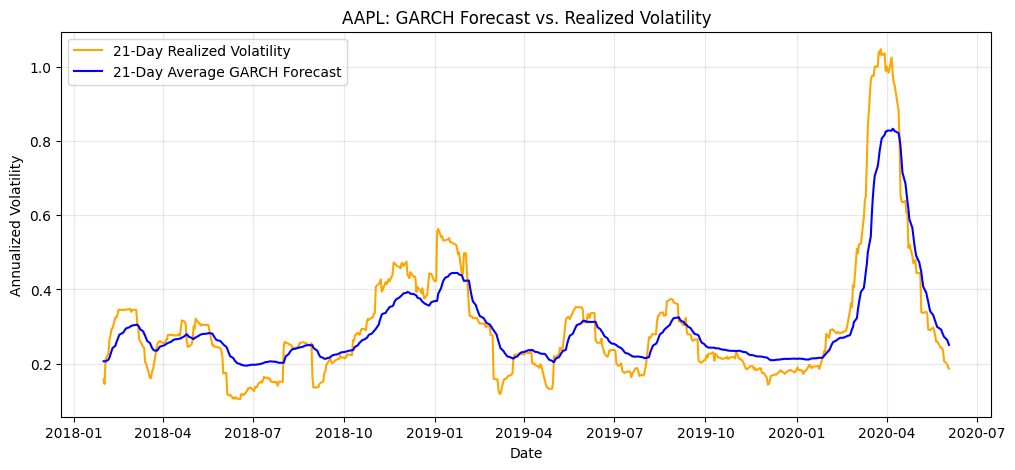

In [9]:
comparison_plot = baseline_evaluation.copy()

# 21-day realized volatility based on squared returns
comparison_plot["Realized_Volatility_21D"] = (
    comparison_plot["Actual_Return"]
    .pow(2)
    .rolling(21)
    .mean()
    .pow(0.5)
    * np.sqrt(252)
)

# 21-day average of GARCH forecasted variances
comparison_plot["Forecasted_Volatility_21D"] = (
    comparison_plot["Forecasted_Variance"]
    .rolling(21)
    .mean()
    .pow(0.5)
    * np.sqrt(252)
)

plt.figure(figsize=(12, 5))

plt.plot(
    comparison_plot.index,
    comparison_plot["Realized_Volatility_21D"],
    label="21-Day Realized Volatility",
    color="orange"
)

plt.plot(
    comparison_plot.index,
    comparison_plot["Forecasted_Volatility_21D"],
    label="21-Day Average GARCH Forecast",
    color="blue"
)

plt.title("AAPL: GARCH Forecast vs. Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Align and aggregate financial-news sentiment

Because exact publication times are unavailable, each article is conservatively
assigned to the next trading day. Articles assigned to the same target date are
aggregated using their mean sentiment score; the number of headlines is retained as
a diagnostic feature. Trading days without usable news receive sentiment zero and
are distinguished using `Has_News`.

In [ ]:
from pathlib import Path

sentiment_path = Path("data") / "tech_sentiment_progress.csv"

if not sentiment_path.exists():
    raise FileNotFoundError(
        "Sentiment data not found. Run the notebook from the repository root "
        "and make sure data/tech_sentiment_progress.csv exists."
    )

sentiment_raw = pd.read_csv(sentiment_path, parse_dates=["date"])
sentiment_raw.head()

In [11]:
# To obtain AAPL trading dates
trading_dates = pd.DatetimeIndex(
    data.index
).normalize()

In [12]:
# Make sure each news item only contributes to the trading dates afterwards
next_trading_positions = trading_dates.searchsorted(
    sentiment_raw["date"],
    side="right"
)

valid_news = (next_trading_positions < len(trading_dates))

# Remove news that exceeds the last market data
sentiment_aligned = sentiment_raw.loc[valid_news].copy()

# target date: the next AAPL trading date that the news can be used
sentiment_aligned["Target_Date"] = trading_dates[
    next_trading_positions[valid_news]
]

In [13]:
sentiment_aligned.head()

        date                                           headline  sentiment  \
0 2019-11-12  Royal London Asset Management Ltd Buys Apple I...          0   
1 2019-11-07  TDAM USA Inc. Buys Phillips 66, DuPont de Nemo...          0   
2 2018-06-02  Stocks To Watch: Eyes On Apple's WWDC, SCOTUS ...          0   
3 2017-11-21  Stocks Up Big As Apple Leads Dow; Is It Time T...          1   
4 2017-05-23  Stocks: Slim Gains Turn Mixed; Nokia Surges On...         -1   

  Target_Date  
0  2019-11-13  
1  2019-11-08  
2  2018-06-04  
3  2017-11-22  
4  2017-05-24  

In [14]:
 # Calculate the mean sentiment score and count for each date in Target_Date
daily_sentiment = (
    sentiment_aligned
    .groupby("Target_Date")
    .agg(
        Sentiment=("sentiment", "mean"),
        Headline_Count=("sentiment", "size")
    )
)

In [15]:
display(daily_sentiment.head(20))

print("Number of target trading days:", len(daily_sentiment))

             Sentiment  Headline_Count
Target_Date                           
2010-03-03    0.000000               2
2010-03-04    1.000000               1
2010-03-05   -0.142857               7
2010-03-08    0.750000               4
2010-03-11    1.000000               1
2010-03-12    0.000000               1
2010-03-16    1.000000               1
2010-03-18    0.000000               1
2010-03-26    0.000000               3
2010-03-30    1.000000               2
2010-03-31    0.000000               3
2010-04-05    0.000000               1
2010-04-06    0.000000               3
2010-04-08    0.000000               3
2010-04-14    0.000000               1
2010-04-21    1.000000               1
2010-04-22    0.000000               1
2010-04-26    1.000000               2
2010-04-28    1.000000               1
2010-05-05    0.000000               1

Number of target trading days: 1879


In [16]:
# Combining trading date data with sentiment score while keeping all the trading dates
model_data = data.join(
    daily_sentiment,
    how="left"
)

# Set trading dates with no sentiment score to 0
model_data["Sentiment"] = (
    model_data["Sentiment"].fillna(0.0)
)

model_data["Headline_Count"] = (
    model_data["Headline_Count"].fillna(0).astype(int)
)

model_data["Has_News"] = (
    model_data["Headline_Count"] > 0
).astype(int)
model_data = model_data.sort_index()

In [17]:
display(
    model_data[
        [
            "Close",
            "Log_Return",
            "Sentiment",
            "Headline_Count",
            "Has_News"
        ]
    ].head(30)
)

               Close  Log_Return  Sentiment  Headline_Count  Has_News
Date                                                                 
2010-02-11  5.942146    0.018030   0.000000               0         0
2010-02-12  5.993292    0.008571   0.000000               0         0
2010-02-16  6.083620    0.014959   0.000000               0         0
2010-02-17  6.058195   -0.004188   0.000000               0         0
2010-02-18  6.069561    0.001874   0.000000               0         0
2010-02-19  6.031876   -0.006228   0.000000               0         0
2010-02-22  5.994488   -0.006218   0.000000               0         0
2010-02-23  5.893991   -0.016907   0.000000               0         0
2010-02-24  6.001667    0.018104   0.000000               0         0
2010-02-25  6.041746    0.006656   0.000000               0         0
2010-02-26  6.120109    0.012887   0.000000               0         0
2010-03-01  6.250816    0.021132   0.000000               0         0
2010-03-02  6.246625

In [18]:
print(model_data.shape)

print(
    "Trading days with available news:",
    model_data["Has_News"].sum()
)

print(
    "Trading days without news:",
    (model_data["Has_News"] == 0).sum()
)

(2595, 5)
Trading days with available news: 1879
Trading days without news: 716


## 5. Sentiment-augmented GARCH model

Sentiment enters the conditional mean equation:

$$r_t = \mu + \gamma S_t + \epsilon_t.$$

The GARCH(1,1) variance equation remains unchanged. The same split date and expanding-
window procedure are used so that the comparison with the baseline is fair.

In [19]:
# Split train and test sets
split_date = "2018-01-01"
train_returns = model_data.loc[model_data.index < split_date, "Log_Return"] * 100
train_sentiment = model_data.loc[model_data.index < split_date, ["Sentiment"]]

test_returns = model_data.loc[model_data.index >= split_date, "Log_Return"] * 100
test_sentiment = model_data.loc[model_data.index >= split_date, ["Sentiment"]]



In [20]:
sentiment_model = arch_model(
    train_returns,
    x=train_sentiment,
    mean="LS",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

sentiment_result = sentiment_model.fit(
    disp="off"
)

print(sentiment_result.summary())

                     Least Squares - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.001
Mean Model:             Least Squares   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3667.25
Distribution:                  Normal   AIC:                           7344.50
Method:            Maximum Likelihood   BIC:                           7372.47
                                        No. Observations:                 1986
Date:                Sun, Sep 13 2026   Df Residuals:                     1984
Time:                        01:35:29   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1394  3.600e-02      3.873  1.076e-04  [6.88

In [23]:
sentiment_forecasts = []

expanding_returns = train_returns.copy()
expanding_sentiment = train_sentiment.copy()

for date in tqdm(test_returns.index):
    model = arch_model(
        expanding_returns,
        x=expanding_sentiment,
        mean="LS",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    result = model.fit(disp="off")

    sentiment_today = test_sentiment.loc[[date]]

    forecast = result.forecast(
        horizon=1,
        x=sentiment_today
    )

    variance_scaled = forecast.variance.iloc[-1, 0]

    sentiment_forecasts.append({
        "Date": date,
        "Forecasted_Variance": variance_scaled / (100 ** 2)
    })

    expanding_returns.loc[date] = test_returns.loc[date]
    expanding_sentiment.loc[date] = test_sentiment.loc[date]

100%|██████████| 609/609 [00:37<00:00, 16.30it/s]


In [24]:
sentiment_forecasts = (
    pd.DataFrame(sentiment_forecasts)
    .set_index("Date")
)

sentiment_evaluation = sentiment_forecasts.copy()

sentiment_evaluation["Actual_Return"] = (
    model_data["Log_Return"]
    .reindex(sentiment_evaluation.index)
)

sentiment_evaluation["Realized_Variance_Proxy"] = (
    sentiment_evaluation["Actual_Return"] ** 2
)

In [25]:
sentiment_mse = np.mean(
    (
        sentiment_evaluation["Forecasted_Variance"]
        - sentiment_evaluation["Realized_Variance_Proxy"]
    ) ** 2
)

In [26]:
sentiment_predicted_variance = sentiment_evaluation[
    "Forecasted_Variance"
].clip(lower=1e-12)

sentiment_qlike = np.mean(
    np.log(sentiment_predicted_variance)
    + sentiment_evaluation["Realized_Variance_Proxy"]
    / sentiment_predicted_variance
)

## 6. Out-of-sample comparison

In [27]:
comparison = pd.DataFrame({
    "Model": ["Baseline GARCH", "GARCH + Sentiment"],
    "MSE": [baseline_mse, sentiment_mse],
    "QLIKE": [baseline_qlike, sentiment_qlike]
})

comparison.style.format({
    "MSE": "{:.8e}",
    "QLIKE": "{:.6f}"
})

               Model       MSE     QLIKE
0     Baseline GARCH  0.000002 -7.051040
1  GARCH + Sentiment  0.000002 -7.051393

## 7. Conclusion

The sentiment-augmented model achieved a slightly lower QLIKE loss, but the difference
was negligible and the MSE values were effectively unchanged. Under this feature
construction, lagged daily-average sentiment did not provide meaningful incremental
predictive value beyond the volatility persistence captured by GARCH(1,1).

### Limitations

- Exact news publication timestamps were unavailable, requiring conservative next-day alignment.
- Daily averaging may hide extreme sentiment and disagreement across headlines.
- Squared daily returns are a noisy proxy for the unobserved latent daily variance.
- The experiment covers one stock and one historical period.